# Progress 分布柱状图

在下面的 `RUN_DIRS_TEXT` 中输入一个或多个 run 文件夹路径，可以每行一个，也可以用逗号或空白分隔。`RUN_LEGEND` 用于设置图中的 legend 名称，数量需要和 run 文件夹数量一致；留空时自动使用目录名。运行代码后会自动读取每个文件夹中的 `eval_results.csv`，并在同一张图中绘制 `progress` 的百分比分布。

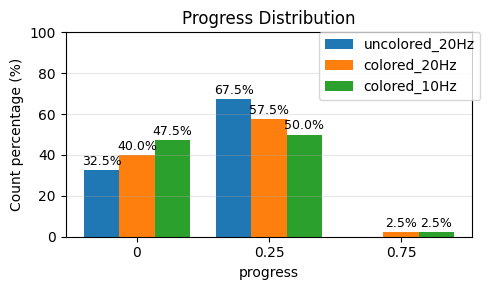

,run,csv_path,episodes
0,uncolored_20Hz,/home/ece-486/Documents/SP_PBL/polaris/runs/PB...,40
1,colored_20Hz,/home/ece-486/Documents/SP_PBL/polaris/runs/PB...,40
2,colored_10Hz,/home/ece-486/Documents/SP_PBL/polaris/runs/PB...,40


,uncolored_20Hz,colored_20Hz,colored_10Hz
progress,,,
0.00,32.5,40.0,47.5
0.25,67.5,57.5,50.0
0.75,0.0,2.5,2.5


In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# 输入一个或多个 run 文件夹路径。支持每行一个，也支持逗号/空白分隔。
RUN_DIRS_TEXT = """
/home/ece-486/Documents/SP_PBL/polaris/runs/PBL-UMI/20260601_093834_no_color_20Hz_40,
/home/ece-486/Documents/SP_PBL/polaris/runs/PBL-UMI/20260601_013528_color_20Hz_40,
/home/ece-486/Documents/SP_PBL/polaris/runs/PBL-UMI/20260601_144514_color_10Hz_40,
"""

# 设置 legend 名称。留空 [] 时自动使用 run 文件夹名。
RUN_LEGEND = [
    "uncolored_20Hz",
    "colored_20Hz",
    "colored_10Hz",
]

RESULT_FILE_NAME = "eval_results.csv"


def parse_run_dirs(text):
    """Parse run directories from multiline/comma/whitespace separated text."""
    parts = re.split(r"[\s,]+", text.strip())
    return [Path(part.strip().strip('"').strip("'")).expanduser() for part in parts if part.strip()]


def find_result_csv(run_dir):
    if run_dir.is_file():
        return run_dir

    candidate = run_dir / RESULT_FILE_NAME
    if candidate.exists():
        return candidate

    raise FileNotFoundError(f"在 {run_dir} 中找不到 {RESULT_FILE_NAME}")


def run_label(path):
    name = path.name
    parent = path.parent.name
    return f"{parent}/{name}" if parent else name


def resolve_run_legends(run_dirs, legends):
    if not legends:
        return [run_label(run_dir) for run_dir in run_dirs]

    if isinstance(legends, str):
        legends = [legend.strip() for legend in re.split(r"[\n,]+", legends) if legend.strip()]

    if len(legends) != len(run_dirs):
        raise ValueError(
            f"RUN_LEGEND 数量 ({len(legends)}) 必须和 run 文件夹数量 ({len(run_dirs)}) 一致"
        )

    return list(legends)


def load_progress_percentages(run_dir, label):
    csv_path = find_result_csv(run_dir)
    df = pd.read_csv(csv_path)
    if "progress" not in df.columns:
        raise ValueError(f"{csv_path} 中没有 progress 列，实际列为: {list(df.columns)}")

    progress = pd.to_numeric(df["progress"], errors="coerce").dropna()
    if progress.empty:
        raise ValueError(f"{csv_path} 的 progress 列没有可用数值")

    counts = progress.value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    return {
        "label": label,
        "csv_path": csv_path,
        "total": int(counts.sum()),
        "counts": counts,
        "percentages": percentages,
    }


def plot_progress_distribution(run_dirs, legends=None):
    if not run_dirs:
        raise ValueError("请至少输入一个 run 文件夹路径")

    labels = resolve_run_legends(run_dirs, legends)
    loaded = [
        load_progress_percentages(run_dir, label)
        for run_dir, label in zip(run_dirs, labels)
    ]
    labels = [item["label"] for item in loaded]
    percentages_list = [item["percentages"] for item in loaded]

    progress_values = sorted(set().union(*(series.index for series in percentages_list)))
    x = np.arange(len(progress_values))
    n_runs = len(percentages_list)
    width = min(0.8 / n_runs, 0.35)

    # 图像大小
    # fig_width = max(8, len(progress_values) * max(0.8, 0.25 * n_runs))
    # fig, ax = plt.subplots(figsize=(fig_width, 5))
    fig, ax = plt.subplots(figsize=(5, 3))

    for idx, (label, percentages) in enumerate(zip(labels, percentages_list)):
        offsets = x + (idx - (n_runs - 1) / 2) * width
        values = [percentages.get(progress_value, 0.0) for progress_value in progress_values]
        bars = ax.bar(offsets, values, width=width, label=label)
        for bar, value in zip(bars, values):
            if value <= 0:
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{value:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_xlabel("progress")
    ax.set_ylabel("Count percentage (%)")
    ax.set_title("Progress Distribution")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{value:g}" for value in progress_values])
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)

    # ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
    ax.legend(loc="best", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

    fig.tight_layout()
    plt.show()

    distribution = pd.DataFrame(
        {item["label"]: item["percentages"] for item in loaded},
        index=progress_values,
    ).fillna(0.0)
    distribution.index.name = "progress"

    summary = pd.DataFrame(
        {
            "run": [item["label"] for item in loaded],
            "csv_path": [str(item["csv_path"]) for item in loaded],
            "episodes": [item["total"] for item in loaded],
        }
    )
    display(summary)
    return distribution


run_dirs = parse_run_dirs(RUN_DIRS_TEXT)
plot_progress_distribution(run_dirs, RUN_LEGEND)
